# STAB1/Clever-1-associated macrophage states in high-grade serous ovarian cancer

## Single-cell RNA-seq reanalysis of GSE224392

This project investigates STAB1 (Clever-1) expression and STAB1-associated macrophage states in high-grade serous ovarian cancer (HGSOC) using publicly available single-cell RNA-sequencing data.

The analysis focuses on:

- identifying macrophage populations and their STAB1 expression patterns,
- characterizing transcriptional differences between macrophage states,
- descriptively comparing Pre-NACT and Post-NACT samples,
- identifying genes consistently associated with STAB1-high macrophages across individual samples.

The dataset contains samples from seven patients: three Pre-NACT and four Post-NACT samples. The Pre- and Post-NACT samples are **not paired samples from the same patients**. Therefore, treatment-group comparisons in this project are descriptive and are not interpreted as causal effects of neoadjuvant chemotherapy.

## Dataset and analysis workflow

The analysis uses the publicly available GSE224392 single-cell RNA-seq dataset from high-grade serous ovarian cancer (HGSOC) omental metastases.

The reconstructed dataset initially contained 65,543 cells and 36,601 genes. After quality control, 63,271 cells were retained for downstream analysis.

The main workflow consisted of:

1. quality control and filtering,
2. normalization and log transformation,
3. selection of highly variable genes,
4. PCA and nearest-neighbor graph construction,
5. Leiden clustering and UMAP visualization,
6. marker-based characterization of macrophage populations,
7. sample-level analysis of STAB1 expression and macrophage-state composition,
8. characterization of genes associated with STAB1-high macrophages.

All Pre-NACT/Post-NACT comparisons are performed at the sample level where appropriate, with individual patients treated as biological replicates.

## Setup and imports

The analysis was performed in Python using Scanpy and standard scientific Python libraries. A fixed random seed is used where applicable to improve reproducibility.

In [ ]:
# Install the main analysis package when running in Google Colab
!pip install -q pandas==2.2.3 scanpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.9 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Scanpy settings
sc.settings.verbosity = 2
sc.settings.set_figure_params(
    dpi=100,
    facecolor="white"
)

print("Scanpy:", sc.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

Scanpy: 1.12
NumPy: 2.1.3
Pandas: 2.2.3


/tmp/ipykernel_1361/602150741.py:12: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(
/tmp/ipykernel_1361/602150741.py:17: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy:", sc.__version__)


## Data loading

The analysis starts from the publicly available GSE224392 single-cell RNA-seq dataset. Raw/processed source data are not stored in this repository because of their size. The dataset can be obtained from the original public repository.

Sample metadata were used to assign the seven samples to Pre-NACT (samples 1–3) and Post-NACT (samples 4–7) groups. These samples originate from different patients and therefore do not constitute paired longitudinal observations.

In [ ]:
import os

os.makedirs("/content/gse224392", exist_ok=True)

!wget -q -O /content/gse224392/GSE224392_RAW.tar \
https://ftp.ncbi.nlm.nih.gov/geo/series/GSE224nnn/GSE224392/suppl/GSE224392_RAW.tar

raw_tar = "/content/gse224392/GSE224392_RAW.tar"

print("Downloaded:", os.path.exists(raw_tar))
print(
    "File size (MB):",
    round(os.path.getsize(raw_tar) / 1024**2, 1)
)

Downloaded: True
File size (MB): 464.4


In [ ]:
!tar -tf /content/gse224392/GSE224392_RAW.tar | head -30

GSM7021604_sample1_barcodes.tsv.gz
GSM7021604_sample1_features.tsv.gz
GSM7021604_sample1_matrix.mtx.gz
GSM7021605_sample1_TCR_filtered_contig_annotations.csv.gz
GSM7021606_sample1_BCR_filtered_contig_annotations.csv.gz
GSM7021607_sample2_barcodes.tsv.gz
GSM7021607_sample2_features.tsv.gz
GSM7021607_sample2_matrix.mtx.gz
GSM7021608_sample2_TCR_filtered_contig_annotations.csv.gz
GSM7021609_sample2_BCR_filtered_contig_annotations.csv.gz
GSM7021610_sample3_barcodes.tsv.gz
GSM7021610_sample3_features.tsv.gz
GSM7021610_sample3_matrix.mtx.gz
GSM7021611_sample3_TCR_filtered_contig_annotations.csv.gz
GSM7021612_sample3_BCR_filtered_contig_annotations.csv.gz
GSM7021613_sample4_barcodes.tsv.gz
GSM7021613_sample4_features.tsv.gz
GSM7021613_sample4_matrix.mtx.gz
GSM7021614_sample4_TCR_filtered_contig_annotations.csv.gz
GSM7021615_sample4_BCR_filtered_contig_annotations.csv.gz
GSM7021616_sample5_barcodes.tsv.gz
GSM7021616_sample5_features.tsv.gz
GSM7021616_sample5_matrix.mtx.gz
GSM7021617_sample5_TC

In [ ]:
# Extract the GEO archive
extract_dir = "/content/gse224392/raw"
os.makedirs(extract_dir, exist_ok=True)

!tar -xf /content/gse224392/GSE224392_RAW.tar -C {extract_dir}

files = sorted(os.listdir(extract_dir))

print("Number of extracted files:", len(files))
print("\nFirst 15 files:")
for f in files[:15]:
    print(f)

Number of extracted files: 35

First 15 files:
GSM7021604_sample1_barcodes.tsv.gz
GSM7021604_sample1_features.tsv.gz
GSM7021604_sample1_matrix.mtx.gz
GSM7021605_sample1_TCR_filtered_contig_annotations.csv.gz
GSM7021606_sample1_BCR_filtered_contig_annotations.csv.gz
GSM7021607_sample2_barcodes.tsv.gz
GSM7021607_sample2_features.tsv.gz
GSM7021607_sample2_matrix.mtx.gz
GSM7021608_sample2_TCR_filtered_contig_annotations.csv.gz
GSM7021609_sample2_BCR_filtered_contig_annotations.csv.gz
GSM7021610_sample3_barcodes.tsv.gz
GSM7021610_sample3_features.tsv.gz
GSM7021610_sample3_matrix.mtx.gz
GSM7021611_sample3_TCR_filtered_contig_annotations.csv.gz
GSM7021612_sample3_BCR_filtered_contig_annotations.csv.gz


In [ ]:
# Load sample 1

sample1 = sc.read_10x_mtx(
    extract_dir,
    prefix="GSM7021604_sample1_",
    var_names="gene_symbols",
    cache=False
)

sample1.var_names_make_unique()

print(sample1)
print("Cells:", sample1.n_obs)
print("Genes:", sample1.n_vars)
print("\nFirst genes:")
print(sample1.var_names[:10].tolist())

AnnData object with n_obs × n_vars = 6194 × 36601
    var: 'gene_ids', 'feature_types'
Cells: 6194
Genes: 36601

First genes:
['MIR1302-2HG', 'FAM138A', 'OR4F5', 'AL627309.1', 'AL627309.3', 'AL627309.2', 'AL627309.5', 'AL627309.4', 'AP006222.2', 'AL732372.1']


In [ ]:
# Load all seven samples

sample_ids = {
    "sample1": "GSM7021604",
    "sample2": "GSM7021607",
    "sample3": "GSM7021610",
    "sample4": "GSM7021613",
    "sample5": "GSM7021616",
    "sample6": "GSM7021619",
    "sample7": "GSM7021622",
}

adatas = []

for sample, gsm in sample_ids.items():
    prefix = f"{gsm}_{sample}_"

    ad = sc.read_10x_mtx(
        extract_dir,
        prefix=prefix,
        var_names="gene_symbols",
        cache=False
    )

    ad.var_names_make_unique()
    ad.obs["sample"] = sample
    adatas.append(ad)

    print(f"{sample}: {ad.n_obs} cells × {ad.n_vars} genes")

sample1: 6194 cells × 36601 genes
sample2: 13520 cells × 36601 genes
sample3: 10148 cells × 36601 genes
sample4: 5997 cells × 36601 genes
sample5: 10287 cells × 36601 genes
sample6: 10364 cells × 36601 genes
sample7: 9033 cells × 36601 genes


In [ ]:
# Combine samples into one AnnData object

adata = sc.concat(
    adatas,
    join="inner",
    label=None,
    index_unique="-"
)

# Treatment group metadata
treatment_map = {
    "sample1": "Pre-NACT",
    "sample2": "Pre-NACT",
    "sample3": "Pre-NACT",
    "sample4": "Post-NACT",
    "sample5": "Post-NACT",
    "sample6": "Post-NACT",
    "sample7": "Post-NACT",
}

adata.obs["treatment"] = adata.obs["sample"].map(treatment_map)

print(adata)
print("\nCells by sample:")
print(adata.obs["sample"].value_counts().sort_index())

print("\nCells by treatment:")
print(adata.obs["treatment"].value_counts())

AnnData object with n_obs × n_vars = 65543 × 36601
    obs: 'sample', 'treatment'

Cells by sample:
sample
sample1     6194
sample2    13520
sample3    10148
sample4     5997
sample5    10287
sample6    10364
sample7     9033
Name: count, dtype: int64

Cells by treatment:
treatment
Post-NACT    35681
Pre-NACT     29862
Name: count, dtype: int64


## Quality control

Quality-control metrics were calculated for each cell before downstream analysis. Mitochondrial genes were identified by the `MT-` prefix, and the number of detected genes, total transcript counts, and mitochondrial transcript fraction were evaluated.

Low-quality cells were filtered before normalization and dimensionality reduction. Quality control was performed on the combined dataset while retaining sample identity for downstream sample-level analyses.

In [ ]:
# Calculate quality-control metrics

adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True
)

print(
    adata.obs[
        ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
    ].describe()
)

print("\nCells before QC:", adata.n_obs)

       n_genes_by_counts   total_counts  pct_counts_mt
count       65543.000000   65543.000000   65543.000000
mean         1906.477168    6698.558594       5.416687
std          1117.434869    7649.160156       7.971369
min            18.000000     500.000000       0.000000
25%          1209.000000    2713.000000       2.378315
50%          1608.000000    4032.000000       3.547320
75%          2406.000000    7632.000000       5.379157
max         11166.000000  163563.000000      98.874245

Cells before QC: 65543


In [ ]:
# Check candidate QC thresholds without filtering adata

for min_genes in [100, 200, 300]:
    for max_genes in [6000, 7500, 10000]:
        for max_mt in [10, 15, 20]:
            keep = (
                (adata.obs["n_genes_by_counts"] >= min_genes) &
                (adata.obs["n_genes_by_counts"] <= max_genes) &
                (adata.obs["pct_counts_mt"] < max_mt)
            )

            n = keep.sum()

            if 63000 <= n <= 63500:
                print(
                    f"min_genes={min_genes}, "
                    f"max_genes={max_genes}, "
                    f"max_mt={max_mt}% -> {n} cells"
                )

min_genes=100, max_genes=6000, max_mt=20% -> 63137 cells
min_genes=100, max_genes=7500, max_mt=20% -> 63448 cells
min_genes=200, max_genes=6000, max_mt=20% -> 63052 cells
min_genes=200, max_genes=7500, max_mt=20% -> 63363 cells
min_genes=200, max_genes=10000, max_mt=20% -> 63424 cells
min_genes=300, max_genes=7500, max_mt=20% -> 63271 cells
min_genes=300, max_genes=10000, max_mt=20% -> 63332 cells


In [ ]:
# Search for the QC threshold combination used in the original analysis

target = 63271

results = []

for min_genes in [100, 200, 300]:
    for max_genes in [5000, 6000, 7000, 7500, 8000, 10000]:
        for max_mt in [10, 15, 20, 25]:
            keep = (
                (adata.obs["n_genes_by_counts"] >= min_genes) &
                (adata.obs["n_genes_by_counts"] <= max_genes) &
                (adata.obs["pct_counts_mt"] < max_mt)
            )

            n = int(keep.sum())

            results.append(
                (abs(n - target), n, min_genes, max_genes, max_mt)
            )

for diff, n, min_genes, max_genes, max_mt in sorted(results)[:10]:
    print(
        f"{n} cells (difference {diff}): "
        f"min_genes={min_genes}, "
        f"max_genes={max_genes}, "
        f"max_mt={max_mt}%"
    )

63271 cells (difference 0): min_genes=300, max_genes=7500, max_mt=20%
63290 cells (difference 19): min_genes=300, max_genes=8000, max_mt=20%
63227 cells (difference 44): min_genes=300, max_genes=7000, max_mt=20%
63319 cells (difference 48): min_genes=200, max_genes=7000, max_mt=20%
63332 cells (difference 61): min_genes=300, max_genes=10000, max_mt=20%
63363 cells (difference 92): min_genes=200, max_genes=7500, max_mt=20%
63382 cells (difference 111): min_genes=200, max_genes=8000, max_mt=20%
63404 cells (difference 133): min_genes=100, max_genes=7000, max_mt=20%
63137 cells (difference 134): min_genes=100, max_genes=6000, max_mt=20%
63424 cells (difference 153): min_genes=200, max_genes=10000, max_mt=20%


In [ ]:
# Apply quality-control filters

n_before = adata.n_obs

adata = adata[
    (adata.obs["n_genes_by_counts"] >= 300) &
    (adata.obs["n_genes_by_counts"] <= 7500) &
    (adata.obs["pct_counts_mt"] < 20)
].copy()

print("Cells before QC:", n_before)
print("Cells after QC:", adata.n_obs)
print("Cells removed:", n_before - adata.n_obs)

Cells before QC: 65543
Cells after QC: 63271
Cells removed: 2272


In [ ]:
# Normalize total counts per cell and log-transform

sc.pp.normalize_total(
    adata,
    target_sum=1e4
)

sc.pp.log1p(adata)

print(adata)
print("Normalization and log1p transformation completed.")

normalizing counts per cell
    finished (0:00:05)
AnnData object with n_obs × n_vars = 63271 × 36601
    obs: 'sample', 'treatment', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'log1p'
Normalization and log1p transformation completed.


In [ ]:
# Identify 3,000 highly variable genes

sc.pp.highly_variable_genes(
    adata,
    n_top_genes=3000,
    flavor="seurat"
)

print("Highly variable genes:", int(adata.var["highly_variable"].sum()))

extracting highly variable genes
    finished (0:00:06)
Highly variable genes: 3000


In [ ]:
# Create an HVG-only object for dimensionality reduction

adata_hvg = adata[:, adata.var["highly_variable"]].copy()

print("Full dataset:", adata.shape)
print("HVG dataset:", adata_hvg.shape)

sc.pp.scale(
    adata_hvg,
    max_value=10
)

print("HVG scaling completed.")

Full dataset: (63271, 36601)
HVG dataset: (63271, 3000)


/usr/lib/python3.13/functools.py:934: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


HVG scaling completed.


In [ ]:
# Principal component analysis using the 3,000 HVGs

sc.tl.pca(
    adata_hvg,
    n_comps=50,
    svd_solver="arpack",
    random_state=RANDOM_SEED
)

print("PCA completed.")
print("PCA coordinates:", adata_hvg.obsm["X_pca"].shape)

computing PCA
    with n_comps=50
    finished (0:01:01)
PCA completed.
PCA coordinates: (63271, 50)


In [ ]:
# Construct the nearest-neighbor graph

sc.pp.neighbors(
    adata_hvg,
    n_neighbors=15,
    n_pcs=30,
    random_state=RANDOM_SEED
)

print("Neighbor graph completed.")

computing neighbors
    using 'X_pca' with n_pcs = 30
    finished (0:01:27)
Neighbor graph completed.


In [ ]:
# Leiden clustering

!pip install -q leidenalg

sc.tl.leiden(
    adata_hvg,
    resolution=1.0,
    random_state=RANDOM_SEED,
    key_added="leiden"
)

print("Number of Leiden clusters:", adata_hvg.obs["leiden"].nunique())
print(adata_hvg.obs["leiden"].value_counts().sort_index())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 91.1 MB/s eta 0:00:00
running Leiden clustering


/tmp/ipykernel_1361/2257169880.py:5: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(


    finished (0:05:25)
Number of Leiden clusters: 31
leiden
0     5923
1     5855
2     5351
3     4997
4     4258
5     3962
6     3645
7     2575
8     2553
9     2526
10    2376
11    2234
12    2171
13    2120
14    1990
15    1542
16    1538
17    1320
18    1161
19    1077
20     951
21     502
22     490
23     473
24     429
25     321
26     319
27     197
28     176
29     134
30     105
Name: count, dtype: int64


In [ ]:
print("Scanpy version:", sc.__version__)

import leidenalg
print("leidenalg version:", leidenalg.__version__)

print("HVGs:", adata_hvg.n_vars)
print("PCA shape:", adata_hvg.obsm["X_pca"].shape)

print("\nNeighbor parameters:")
print(adata_hvg.uns["neighbors"]["params"])

print("\nLeiden clusters:", adata_hvg.obs["leiden"].nunique())

Scanpy version: 1.12
leidenalg version: 0.12.0
HVGs: 3000
PCA shape: (63271, 50)

Neighbor parameters:
{'n_neighbors': 15, 'method': 'umap', 'random_state': 42, 'metric': 'euclidean', 'n_pcs': 30}

Leiden clusters: 31


/tmp/ipykernel_1361/729154263.py:1: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print("Scanpy version:", sc.__version__)


In [ ]:
# Compare Leiden implementations without changing the existing clustering

sc.tl.leiden(
    adata_hvg,
    resolution=1.0,
    random_state=RANDOM_SEED,
    flavor="igraph",
    n_iterations=2,
    key_added="leiden_igraph"
)

print(
    "Current Leiden clusters:",
    adata_hvg.obs["leiden"].nunique()
)

print(
    "igraph Leiden clusters:",
    adata_hvg.obs["leiden_igraph"].nunique()
)

running Leiden clustering
    finished (0:00:10)
Current Leiden clusters: 31
igraph Leiden clusters: 32


In [ ]:
# Use the reproducible igraph Leiden solution as the final clustering

adata_hvg.obs["leiden"] = adata_hvg.obs["leiden_igraph"].copy()

print("Final number of Leiden clusters:", adata_hvg.obs["leiden"].nunique())
print("Cluster labels:", adata_hvg.obs["leiden"].cat.categories.tolist())

Final number of Leiden clusters: 32
Cluster labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31']


In [ ]:
# Save checkpoints to Google Drive

from google.colab import drive
drive.mount("/content/drive")

checkpoint_dir = "/content/drive/MyDrive/STAB1_project"
os.makedirs(checkpoint_dir, exist_ok=True)

adata.write_h5ad(
    f"{checkpoint_dir}/adata_normalized_QC.h5ad",
    compression="gzip"
)

adata_hvg.write_h5ad(
    f"{checkpoint_dir}/adata_HVG_PCA_Leiden.h5ad",
    compression="gzip"
)

print("Checkpoints saved:")
print(f"{checkpoint_dir}/adata_normalized_QC.h5ad")
print(f"{checkpoint_dir}/adata_HVG_PCA_Leiden.h5ad")

MessageError: Error: credential propagation was unsuccessful

In [ ]:
# Save checkpoints locally in the Colab runtime

adata.write_h5ad(
    "/content/adata_normalized_QC.h5ad",
    compression="gzip"
)

adata_hvg.write_h5ad(
    "/content/adata_HVG_PCA_Leiden.h5ad",
    compression="gzip"
)

import os

for path in [
    "/content/adata_normalized_QC.h5ad",
    "/content/adata_HVG_PCA_Leiden.h5ad"
]:
    print(
        os.path.basename(path),
        round(os.path.getsize(path) / 1024**2, 1),
        "MB"
    )

adata_normalized_QC.h5ad 287.7 MB
adata_HVG_PCA_Leiden.h5ad 80.7 MB


In [ ]:
from google.colab import files

files.download("/content/adata_normalized_QC.h5ad")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files

files.download("/content/adata_HVG_PCA_Leiden.h5ad")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Compute UMAP embedding

sc.tl.umap(
    adata_hvg,
    random_state=RANDOM_SEED
)

print("UMAP completed.")
print("UMAP coordinates:", adata_hvg.obsm["X_umap"].shape)

computing UMAP
    finished (0:01:23)
UMAP completed.
UMAP coordinates: (63271, 2)


In [ ]:
# Transfer UMAP coordinates and final Leiden clusters
# to the full-gene AnnData object

adata.obsm["X_umap"] = adata_hvg.obsm["X_umap"].copy()
adata.obs["leiden"] = adata_hvg.obs["leiden"].copy()

print("Full dataset:", adata.shape)
print("UMAP:", adata.obsm["X_umap"].shape)
print("Leiden clusters:", adata.obs["leiden"].nunique())

Full dataset: (63271, 36601)
UMAP: (63271, 2)
Leiden clusters: 32


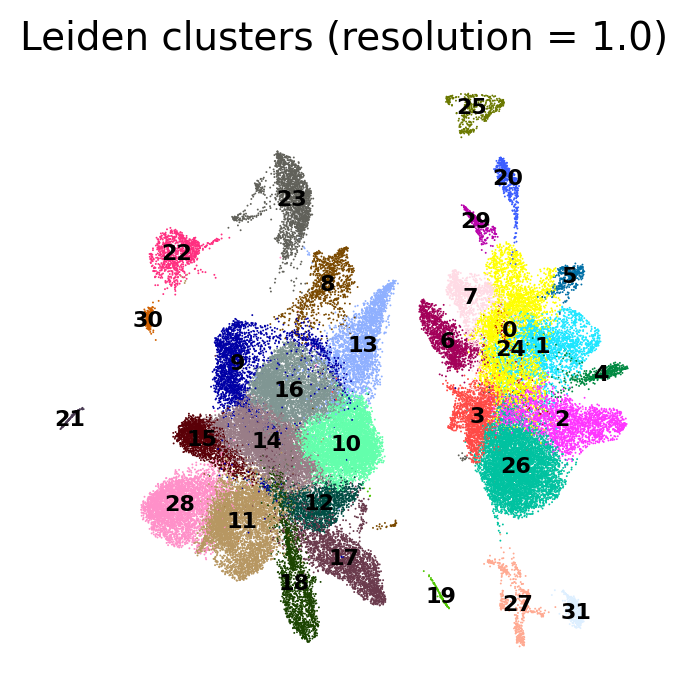

In [ ]:
# Visualize the final Leiden clustering

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    legend_fontsize=8,
    frameon=False,
    title="Leiden clusters (resolution = 1.0)",
    show=True
)

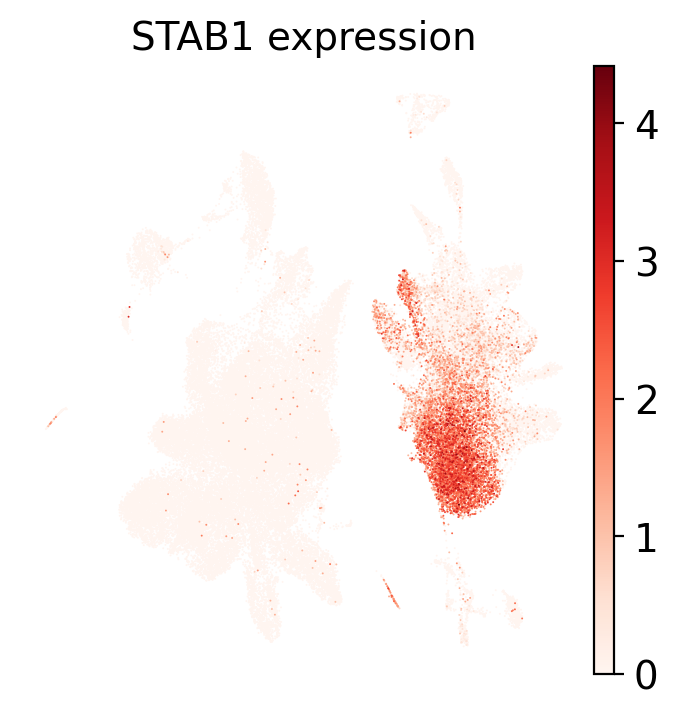

In [ ]:
# Visualize STAB1 expression across the UMAP

sc.pl.umap(
    adata,
    color="STAB1",
    cmap="Reds",
    frameon=False,
    title="STAB1 expression",
    show=True
)

In [ ]:
# Summarize STAB1 expression by Leiden cluster

stab1 = adata[:, "STAB1"].X

if hasattr(stab1, "toarray"):
    stab1 = stab1.toarray()

stab1 = np.asarray(stab1).ravel()

stab1_df = pd.DataFrame({
    "cluster": adata.obs["leiden"].astype(str).values,
    "STAB1": stab1
})

stab1_cluster_summary = (
    stab1_df.groupby("cluster", observed=True)
    .agg(
        n_cells=("STAB1", "size"),
        n_STAB1_positive=("STAB1", lambda x: (x > 0).sum()),
        mean_STAB1=("STAB1", "mean")
    )
)

stab1_cluster_summary["pct_STAB1_positive"] = (
    100 *
    stab1_cluster_summary["n_STAB1_positive"] /
    stab1_cluster_summary["n_cells"]
)

stab1_cluster_summary = stab1_cluster_summary.sort_values(
    "mean_STAB1",
    ascending=False
)

stab1_cluster_summary.head(10)

,n_cells,n_STAB1_positive,mean_STAB1,pct_STAB1_positive
cluster,,,,
26,6224,4640,1.374211,74.550129
3,1798,1176,0.869042,65.406007
7,1036,721,0.777097,69.594595
19,105,56,0.667467,53.333333
2,2429,888,0.481461,36.558254
1,2422,923,0.348232,38.109001
6,1300,350,0.334999,26.923077
0,3645,1035,0.265102,28.395062
21,134,10,0.096818,7.462687


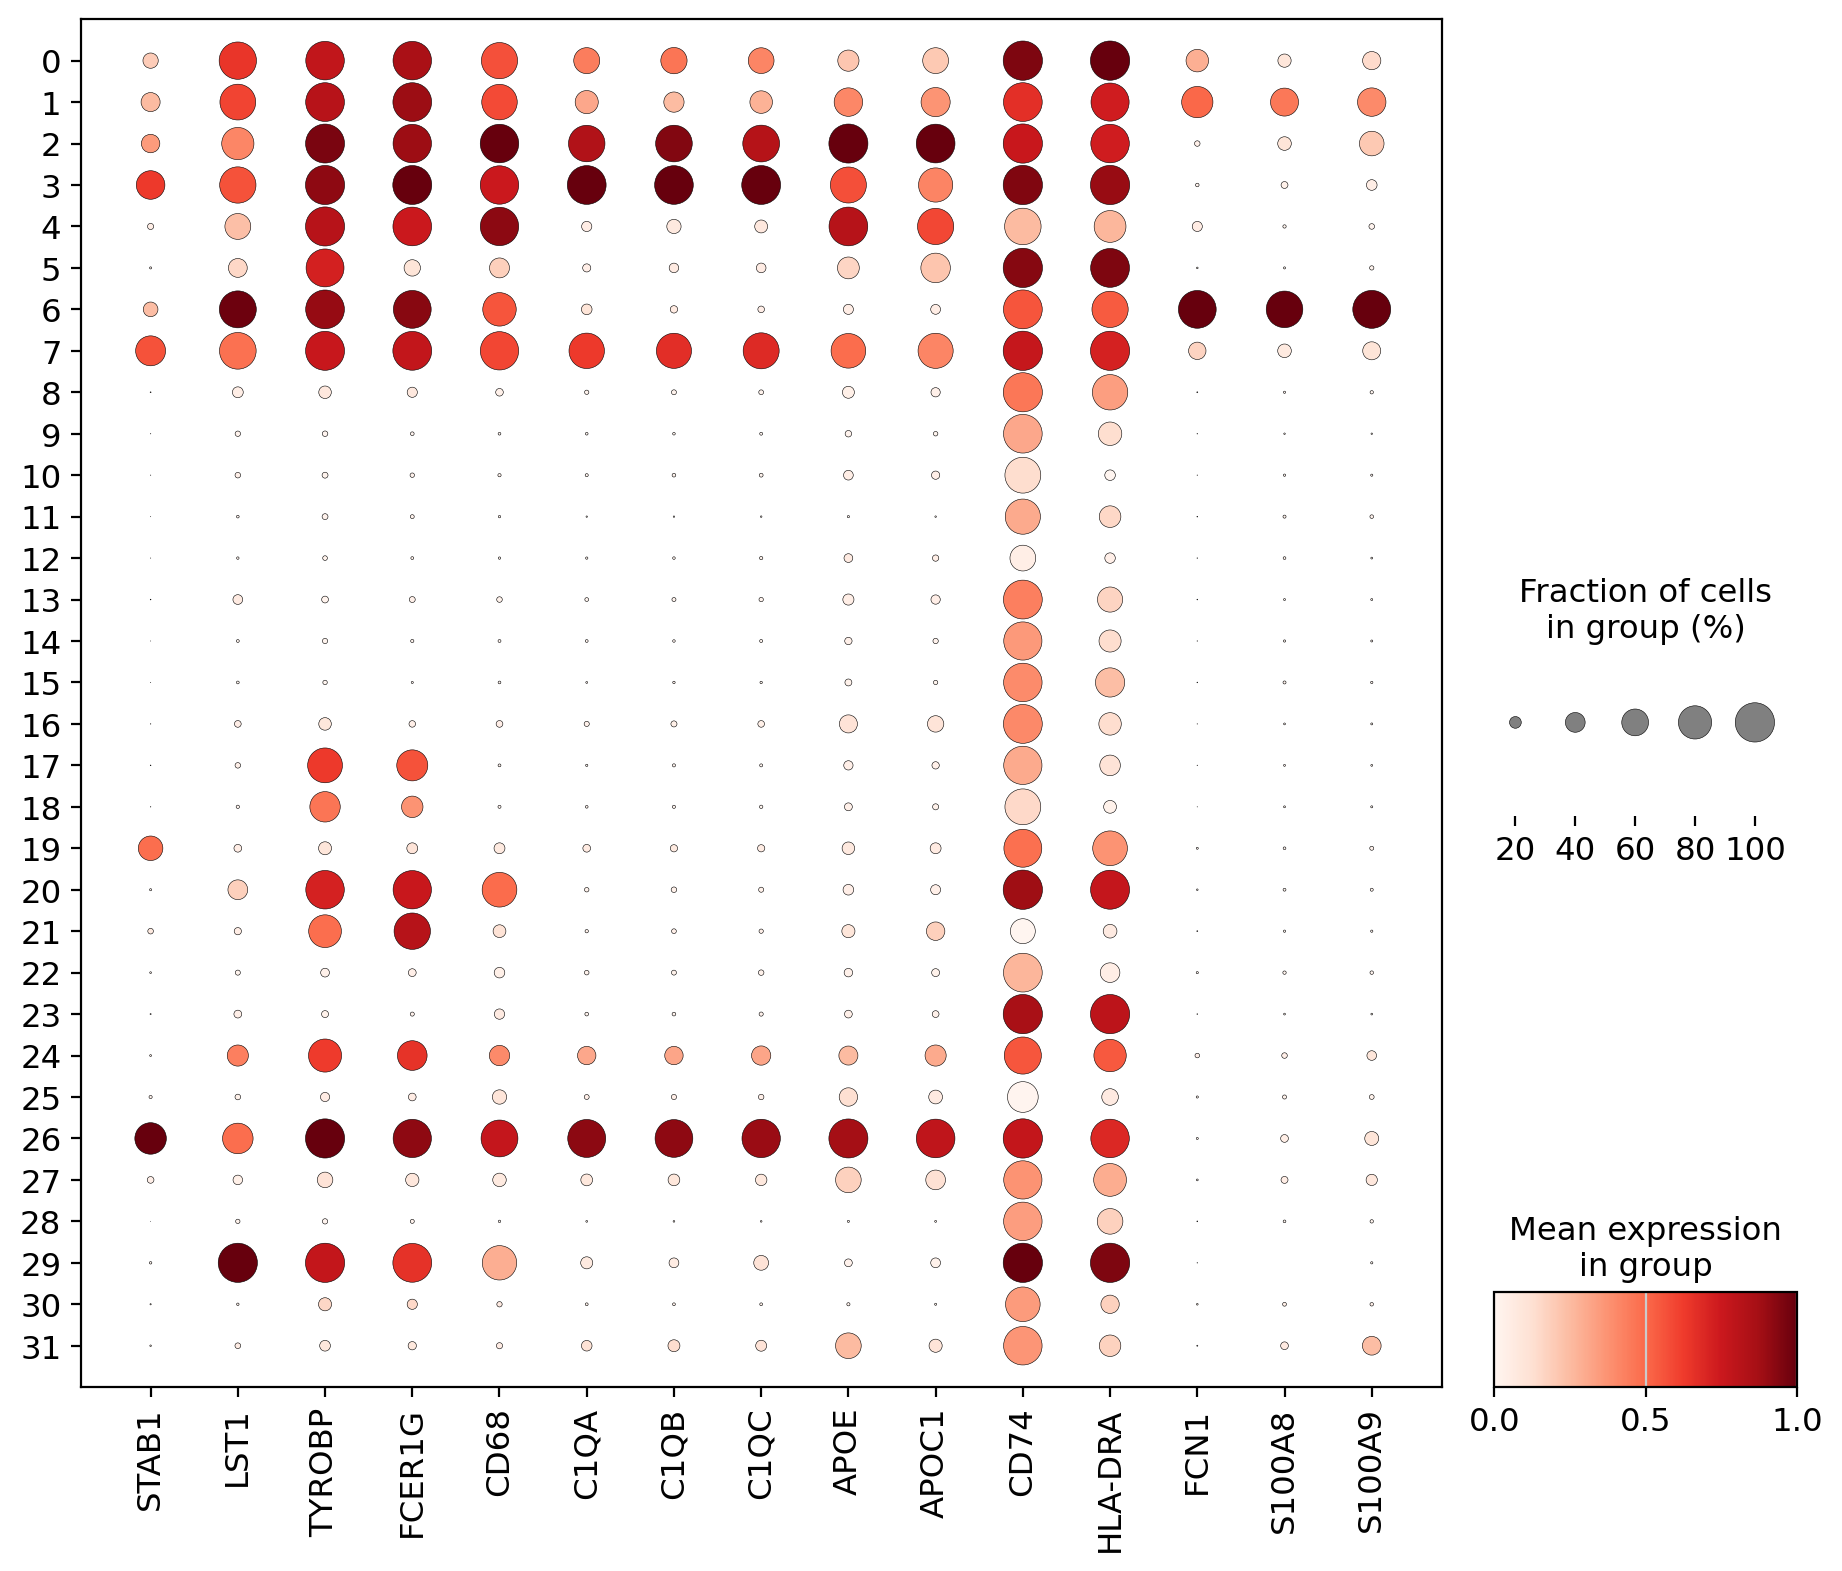

In [ ]:
# Canonical markers for identifying STAB1-rich clusters

marker_genes = [
    "STAB1",
    "LST1", "TYROBP", "FCER1G", "CD68",
    "C1QA", "C1QB", "C1QC",
    "APOE", "APOC1",
    "CD74", "HLA-DRA",
    "FCN1", "S100A8", "S100A9"
]

sc.pl.dotplot(
    adata,
    marker_genes,
    groupby="leiden",
    standard_scale="var",
    dendrogram=False,
    figsize=(11, 9)
)

In [ ]:
# Identify marker genes for the main STAB1-rich macrophage clusters

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    groups=["26", "3", "7"],
    reference="rest",
    method="wilcoxon",
    key_added="macrophage_markers"
)

for cluster in ["26", "3", "7"]:
    print(f"\nCluster {cluster}")
    display(
        sc.get.rank_genes_groups_df(
            adata,
            group=cluster,
            key="macrophage_markers"
        )[["names", "logfoldchanges", "pvals_adj"]].head(15)
    )

ranking genes
    finished (0:04:36)

Cluster 26


,names,logfoldchanges,pvals_adj
0,RNASE1,6.064900,0.0
1,SPP1,5.890702,0.0
2,APOE,6.183579,0.0
3,FTL,3.767653,0.0
4,TYROBP,4.432727,0.0
5,APOC1,5.462231,0.0
6,C1QC,5.132828,0.0
7,C1QA,4.939650,0.0
8,AIF1,3.912849,0.0
9,C1QB,4.839696,0.0



Cluster 3


,names,logfoldchanges,pvals_adj
0,C3,4.535154,0.0
1,C1QC,5.073381,0.0
2,C1QA,4.679788,0.0
3,CD74,3.267838,0.0
4,HLA-DPA1,3.298007,0.0
5,C1QB,4.633718,0.0
6,HLA-DRB1,3.396372,0.0
7,NPC2,3.254942,0.0
8,PLD4,4.415164,0.0
9,CST3,4.186771,0.0



Cluster 7


,names,logfoldchanges,pvals_adj
0,TUBA1B,3.968348,0.0
1,STMN1,4.789845,0.0
2,H2AFZ,3.398203,0.0
3,TUBB,3.458464,0.0
4,HMGN2,2.802896,0.0
5,MKI67,5.299077,0.0
6,HMGB1,2.016357,0.0
7,UBE2C,5.862752,0.0
8,TYMS,5.102254,0.0
9,CENPF,4.790157,0.0


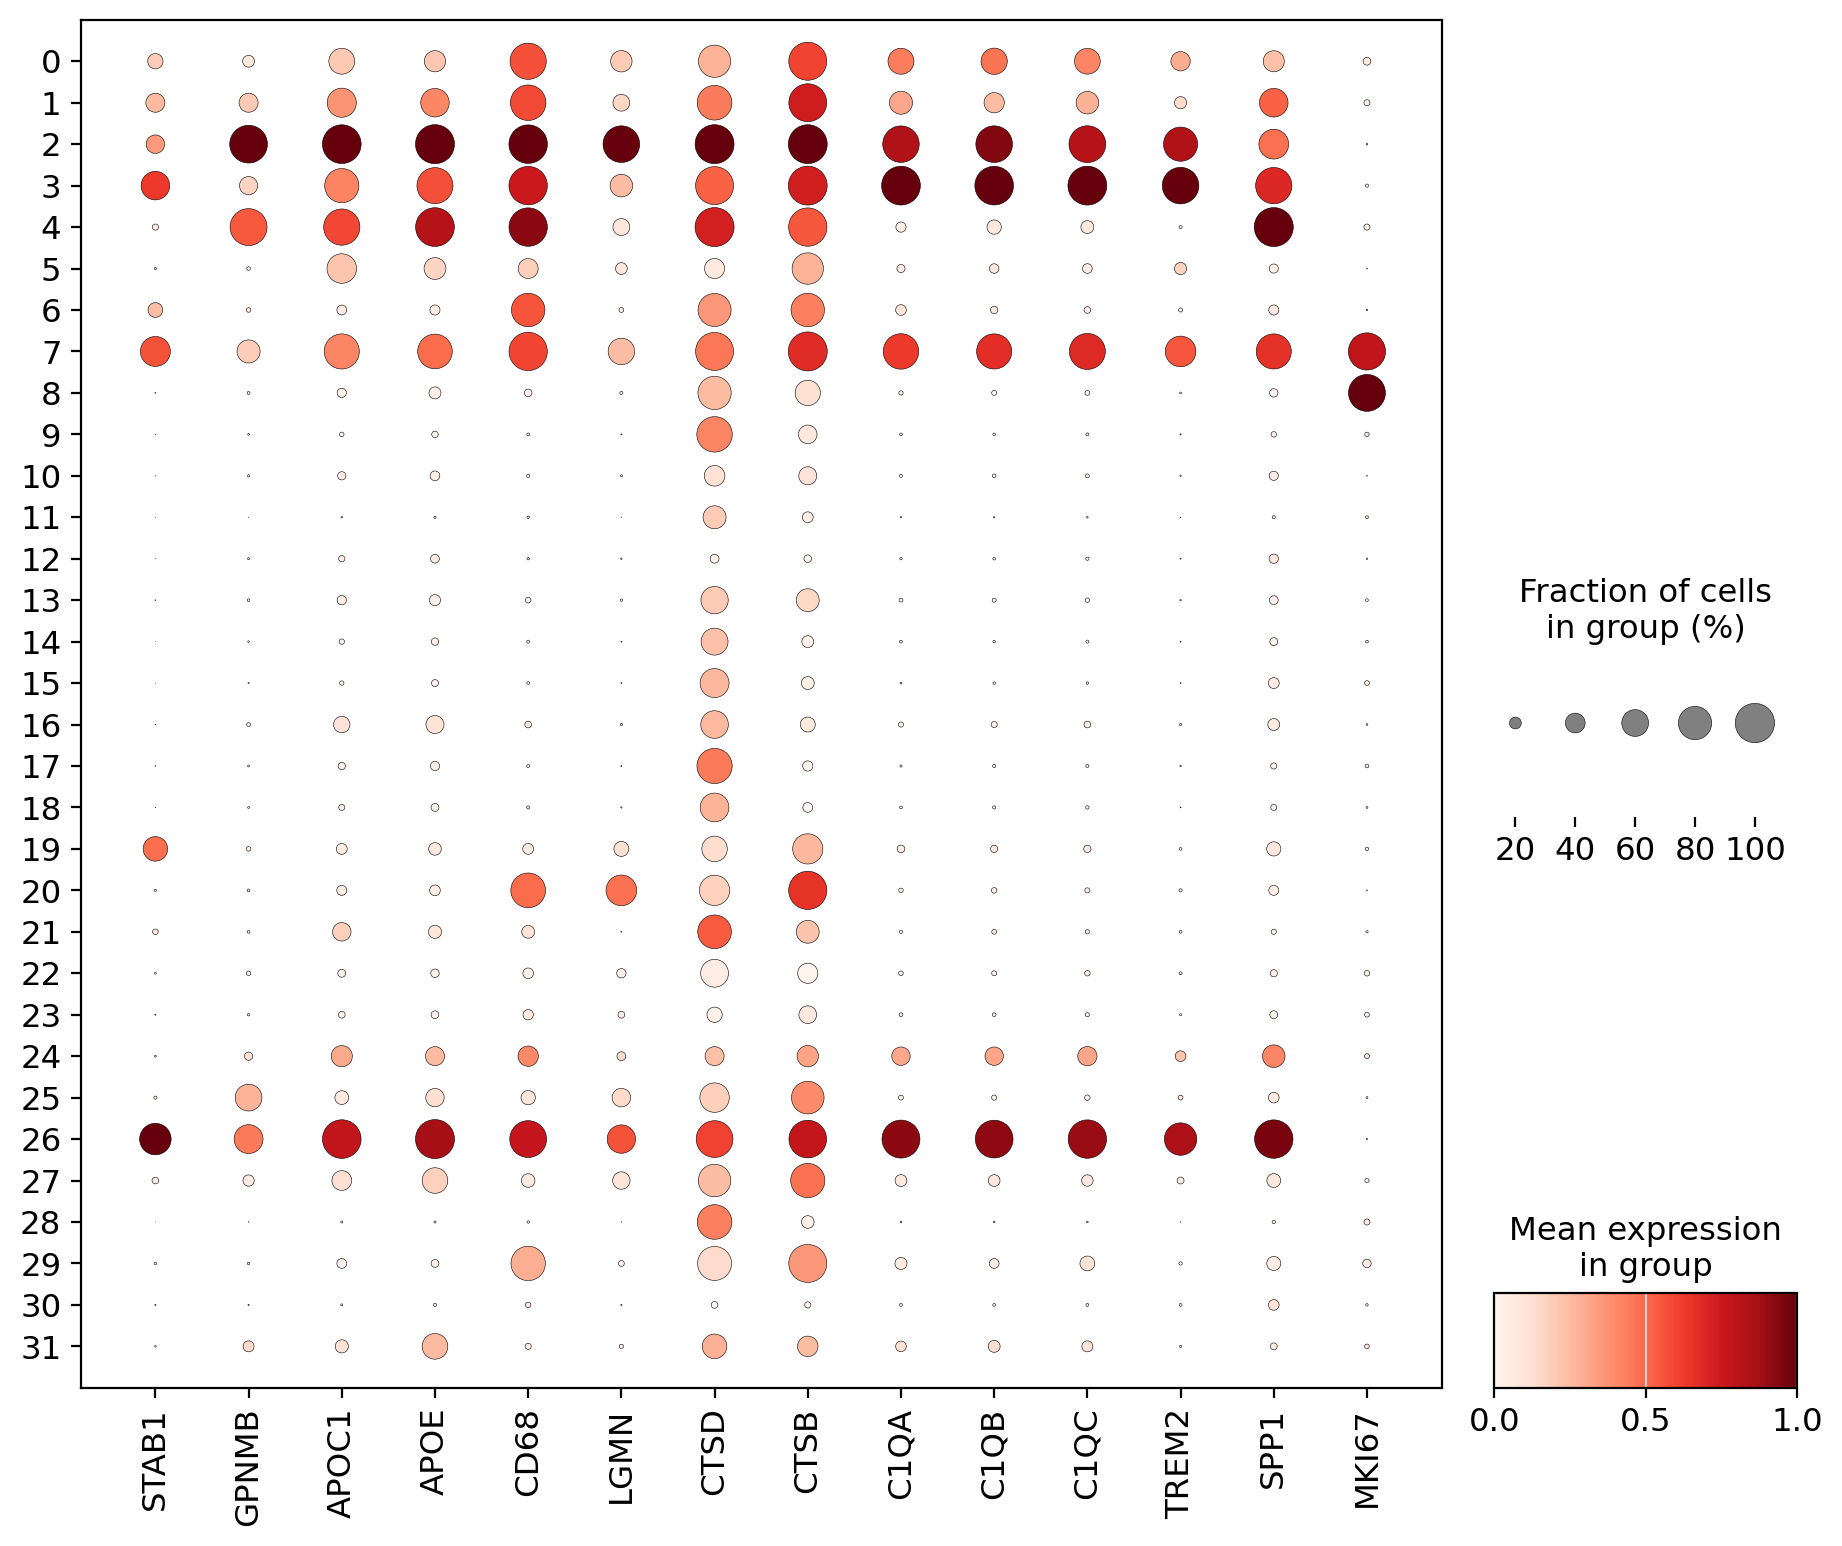

In [ ]:
# Locate the GPNMB/APOC1 macrophage state

state_markers = [
    "STAB1",
    "GPNMB", "APOC1", "APOE",
    "CD68", "LGMN", "CTSD", "CTSB",
    "C1QA", "C1QB", "C1QC",
    "TREM2", "SPP1",
    "MKI67"
]

sc.pl.dotplot(
    adata,
    state_markers,
    groupby="leiden",
    standard_scale="var",
    dendrogram=False,
    figsize=(11, 9)
)

In [ ]:
# Marker genes for the remaining macrophage-like clusters

sc.tl.rank_genes_groups(
    adata,
    groupby="leiden",
    groups=["0", "2", "4"],
    reference="rest",
    method="wilcoxon",
    key_added="additional_macrophage_markers"
)

for cluster in ["0", "2", "4"]:
    print(f"\nCluster {cluster}")
    display(
        sc.get.rank_genes_groups_df(
            adata,
            group=cluster,
            key="additional_macrophage_markers"
        )[["names", "logfoldchanges", "pvals_adj"]].head(15)
    )

ranking genes
    finished (0:04:15)

Cluster 0


,names,logfoldchanges,pvals_adj
0,HLA-DRA,4.663573,0.0
1,HLA-DRB1,3.988912,0.0
2,HLA-DQB1,4.417819,0.0
3,HLA-DQA1,4.464992,0.0
4,HLA-DPA1,3.651349,0.0
5,HLA-DPB1,3.608335,0.0
6,CD74,3.389271,0.0
7,CTSH,3.401689,0.0
8,ALDH2,3.701798,0.0
9,HLA-DMA,2.911885,0.0



Cluster 2


,names,logfoldchanges,pvals_adj
0,FTL,4.566889,0.0
1,APOC1,6.443376,0.0
2,GPNMB,5.649645,0.0
3,APOE,6.576859,0.0
4,CTSD,3.747737,0.0
5,PSAP,3.813816,0.0
6,CTSB,3.834705,0.0
7,CD68,4.220375,0.0
8,CTSS,3.277898,0.0
9,LGMN,4.789632,0.0



Cluster 4


,names,logfoldchanges,pvals_adj
0,ACP5,6.956975,7.845452e-269
1,MMP9,8.008971,2.249781e-260
2,CTSK,8.855095,6.448233e-258
3,RGS10,3.818771,1.495182e-257
4,CST3,6.556838,5.465086e-246
5,ANPEP,5.293328,3.010766e-231
6,ATP6V0C,2.999518,1.730121e-225
7,SNHG29,2.770202,8.973030e-220
8,SLC9B2,7.052460,9.463421e-217
9,SPARC,5.671882,6.359443e-215


In [ ]:
# STAB1 expression in the identified macrophage/myeloid states

macrophage_clusters = ["0", "2", "3", "4", "7", "26"]

macrophage_STAB1 = (
    stab1_cluster_summary
    .loc[macrophage_clusters]
    .copy()
    .sort_values("mean_STAB1", ascending=False)
)

display(macrophage_STAB1)

macrophage_STAB1.to_csv(
    "/content/STAB1_macrophage_states_summary.csv"
)

print("Saved: /content/STAB1_macrophage_states_summary.csv")

,n_cells,n_STAB1_positive,mean_STAB1,pct_STAB1_positive
cluster,,,,
26,6224,4640,1.374211,74.550129
3,1798,1176,0.869042,65.406007
7,1036,721,0.777097,69.594595
2,2429,888,0.481461,36.558254
0,3645,1035,0.265102,28.395062
4,428,36,0.062067,8.411215


Saved: /content/STAB1_macrophage_states_summary.csv


In [ ]:
# STAB1 expression by sample and macrophage state

macro = adata.obs["leiden"].astype(str).isin(
    ["0", "2", "3", "4", "7", "26"]
)

df = pd.DataFrame({
    "sample": adata.obs.loc[macro, "sample"].values,
    "treatment": adata.obs.loc[macro, "treatment"].values,
    "cluster": adata.obs.loc[macro, "leiden"].astype(str).values,
    "STAB1": stab1[macro]
})

STAB1_by_sample = (
    df.groupby(
        ["sample", "treatment", "cluster"],
        observed=True
    )
    .agg(
        n_cells=("STAB1", "size"),
        n_STAB1_positive=("STAB1", lambda x: (x > 0).sum()),
        mean_STAB1=("STAB1", "mean")
    )
    .reset_index()
)

STAB1_by_sample["pct_STAB1_positive"] = (
    100 *
    STAB1_by_sample["n_STAB1_positive"] /
    STAB1_by_sample["n_cells"]
)

display(STAB1_by_sample)

STAB1_by_sample.to_csv(
    "/content/STAB1_macrophage_states_by_sample.csv",
    index=False
)

print("Saved: /content/STAB1_macrophage_states_by_sample.csv")

,sample,treatment,cluster,n_cells,n_STAB1_positive,mean_STAB1,pct_STAB1_positive
0,sample1,Pre-NACT,0,1195,192,0.108958,16.066946
1,sample1,Pre-NACT,2,99,39,0.465469,39.393939
2,sample1,Pre-NACT,26,14,10,0.900578,71.428571
3,sample1,Pre-NACT,3,7,1,0.127634,14.285714
4,sample1,Pre-NACT,4,264,17,0.037416,6.439394
5,sample1,Pre-NACT,7,203,104,0.235498,51.231527
6,sample2,Pre-NACT,0,401,55,0.093763,13.715711
7,sample2,Pre-NACT,2,12,11,1.069017,91.666667
8,sample2,Pre-NACT,26,33,21,0.796990,63.636364
9,sample2,Pre-NACT,3,73,31,0.383500,42.465753


Saved: /content/STAB1_macrophage_states_by_sample.csv


## STAB1 expression across macrophage states

STAB1 expression was concentrated in myeloid/macrophage populations but varied substantially between transcriptionally distinct macrophage states.

The strongest STAB1 expression was observed in cluster 26, characterized by SPP1, APOE, APOC1 and C1Q-family genes. Approximately 75% of cells in this cluster showed detectable STAB1 expression. Other macrophage states showed intermediate or substantially lower STAB1 expression.

Marker-gene analysis identified several transcriptionally distinct myeloid states, including HLA class II-high, GPNMB/APOC1 lysosomal, SPP1/C1Q, proliferating, and ACP5/CTSK-associated populations.

STAB1 expression also varied considerably between individual samples. Because the dataset contains only three Pre-NACT and four Post-NACT patients and the groups are not paired, these differences are interpreted descriptively rather than as evidence of a treatment effect.

## Limitations and conclusions

### Limitations

The dataset contains a large number of individual cells but only seven independent patient samples: three Pre-NACT and four Post-NACT samples. The treatment groups consist of different patients rather than paired longitudinal samples. Consequently, the large number of cells does not increase the number of independent biological replicates for treatment-group comparisons.

Substantial inter-sample heterogeneity was observed in both macrophage-state abundance and STAB1 expression. Therefore, Pre-NACT versus Post-NACT differences should be considered descriptive and cannot establish a causal effect of neoadjuvant chemotherapy.

Single-cell RNA-seq also contains technical dropout, meaning that absence of detectable STAB1 transcripts in an individual cell does not necessarily indicate true biological absence of STAB1 expression.

### Conclusions

STAB1 expression was predominantly associated with myeloid/macrophage populations and differed substantially among transcriptionally distinct macrophage states.

The highest STAB1 expression was observed in an SPP1/APOE/APOC1/C1Q-associated macrophage population, while other macrophage states showed intermediate or low expression.

Overall, the results support substantial heterogeneity of STAB1 expression within the tumor-associated myeloid compartment. The limited number of independent patient samples prevents strong conclusions about treatment-associated changes, and validation in larger independent cohorts would be required to test such effects.

## Reproducibility and data availability

The analysis was performed in Python using Scanpy. A fixed random seed was used for stochastic analysis steps to improve reproducibility.

The analysis starts from the publicly available GSE224392 single-cell RNA-seq dataset and includes quality control, normalization, highly variable gene selection, PCA, neighborhood graph construction, Leiden clustering, UMAP visualization, marker-gene analysis, and STAB1 expression analysis.

The processed `.h5ad` files are not included in this repository because of their size. The analysis notebook documents the workflow required to reconstruct the analyzed dataset from the publicly available source data.

Key summary tables and figures generated by the analysis are provided in the `results/` and `figures/` directories.

In [ ]:
from pathlib import Path

FIGURES_DIR = Path("/content/figures")
RESULTS_DIR = Path("/content/results")

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

print("Created:")
print(FIGURES_DIR)
print(RESULTS_DIR)

Created:
/content/figures
/content/results


In [ ]:
import shutil

files_to_copy = [
    "STAB1_macrophage_states_summary.csv",
    "STAB1_macrophage_states_by_sample.csv",
]

for filename in files_to_copy:
    source = Path("/content") / filename
    destination = RESULTS_DIR / filename

    if source.exists():
        shutil.copy2(source, destination)
        print(f"Copied: {filename}")
    else:
        print(f"NOT FOUND: {filename}")

Copied: STAB1_macrophage_states_summary.csv
Copied: STAB1_macrophage_states_by_sample.csv


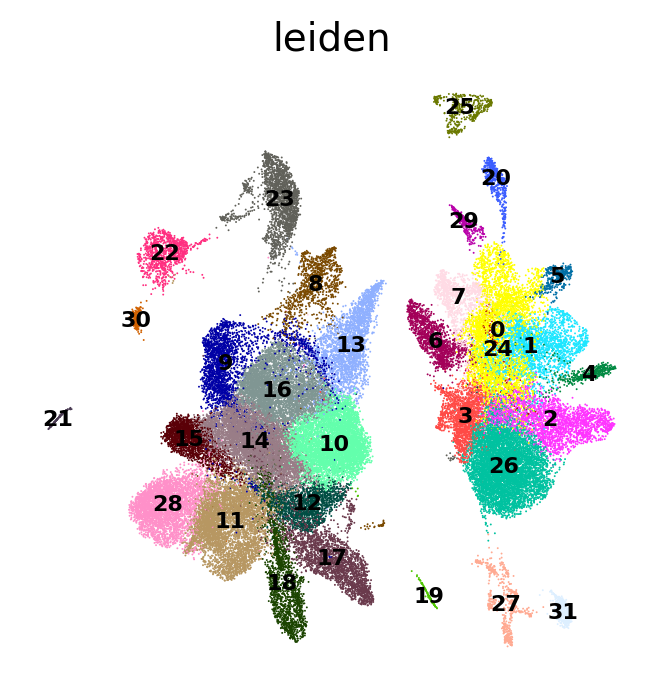

Saved: /content/figures/UMAP_Leiden_clusters.png


In [ ]:
# Save Leiden cluster UMAP for GitHub

sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data",
    legend_fontsize=8,
    frameon=False,
    show=False
)

plt.savefig(
    FIGURES_DIR / "UMAP_Leiden_clusters.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FIGURES_DIR / "UMAP_Leiden_clusters.png")

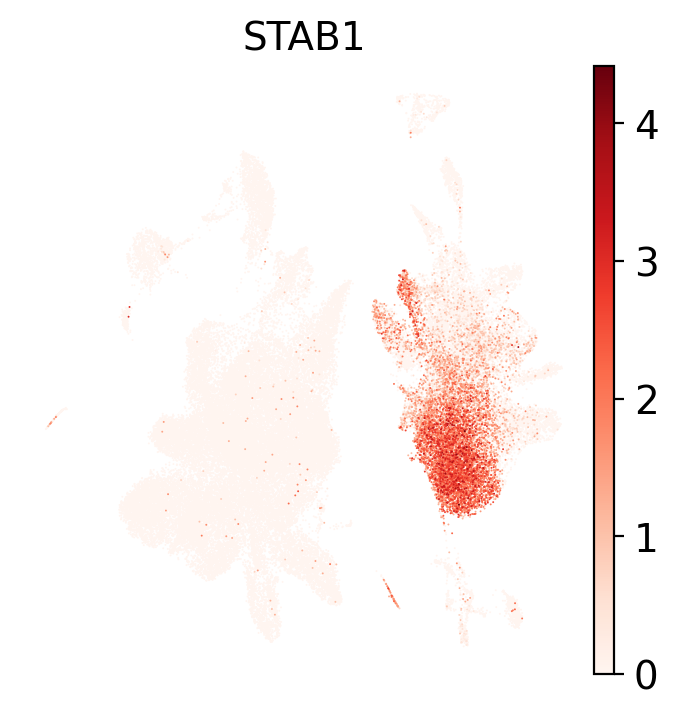

Saved: /content/figures/UMAP_STAB1_expression.png


In [ ]:
# Save STAB1 expression UMAP for GitHub

sc.pl.umap(
    adata,
    color="STAB1",
    cmap="Reds",
    frameon=False,
    show=False
)

plt.savefig(
    FIGURES_DIR / "UMAP_STAB1_expression.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FIGURES_DIR / "UMAP_STAB1_expression.png")

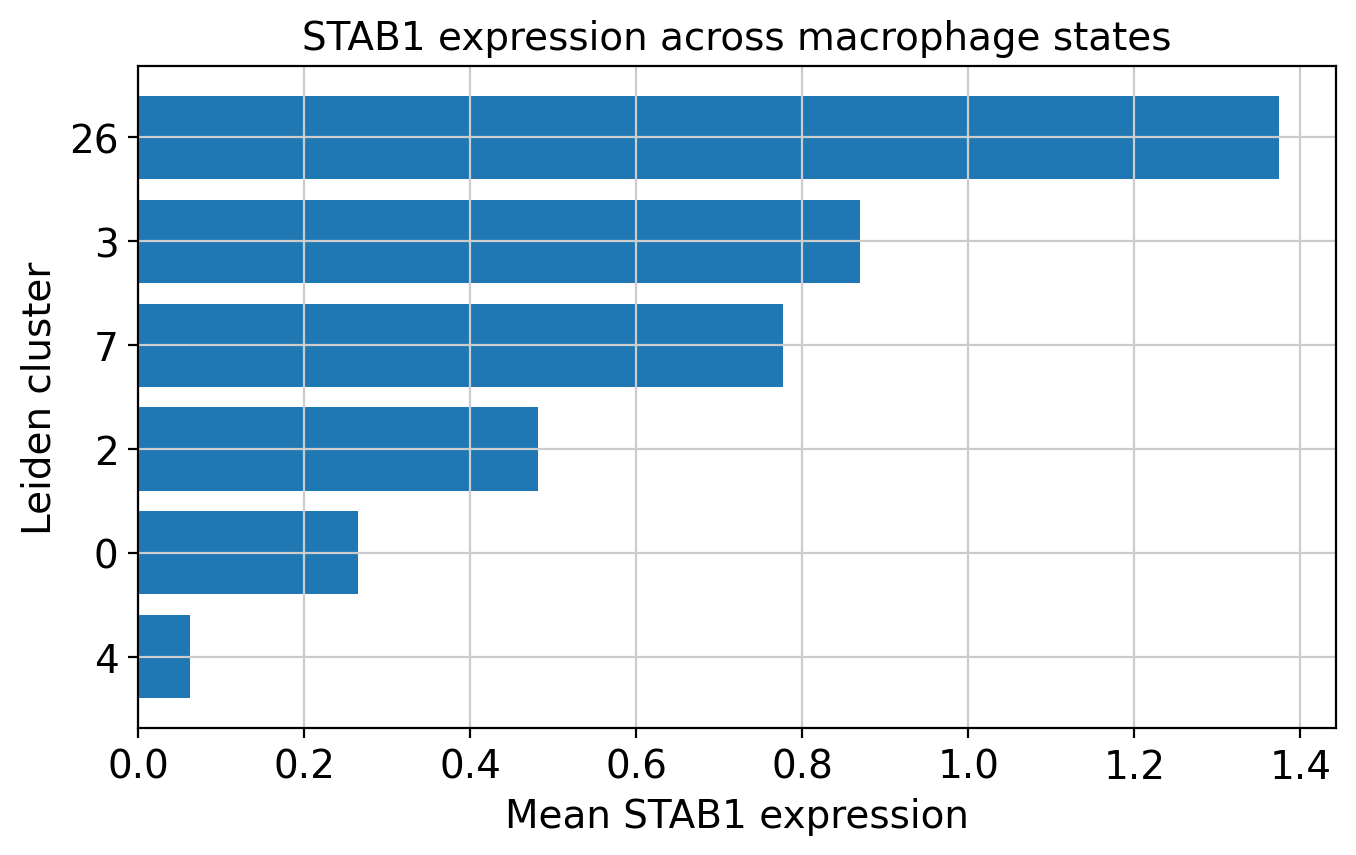

Saved: /content/figures/STAB1_macrophage_states.png


In [ ]:
# STAB1 expression across macrophage states

plot_df = macrophage_STAB1.sort_values(
    "mean_STAB1",
    ascending=True
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.barh(
    plot_df.index.astype(str),
    plot_df["mean_STAB1"]
)

ax.set_xlabel("Mean STAB1 expression")
ax.set_ylabel("Leiden cluster")
ax.set_title("STAB1 expression across macrophage states")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "STAB1_macrophage_states.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", FIGURES_DIR / "STAB1_macrophage_states.png")

In [ ]:
print("FIGURES")
for f in sorted(FIGURES_DIR.iterdir()):
    print(" -", f.name)

print("\nRESULTS")
for f in sorted(RESULTS_DIR.iterdir()):
    print(" -", f.name)

FIGURES
 - STAB1_macrophage_states.png
 - UMAP_Leiden_clusters.png
 - UMAP_STAB1_expression.png

RESULTS
 - STAB1_macrophage_states_by_sample.csv
 - STAB1_macrophage_states_summary.csv


## Correspondence between exploratory and reconstructed clustering

The original exploratory analysis and the final reconstructed workflow produced
different Leiden partitions. Cluster numbers are therefore analysis-specific and
must not be interpreted as equivalent between the two workflows.

Several major macrophage states nevertheless showed similar marker profiles:

| Exploratory clustering | Reconstructed clustering | Marker profile / interpretation |
|---|---|---|
| Cluster 0 | Cluster 26 | STAB1-high, SPP1, APOE, APOC1, C1QA/B/C macrophages |
| Cluster 5 | Cluster 3 | C1Q, HLA class II, CD74, TREM2 macrophages |
| Cluster 11 | Cluster 2 | GPNMB, APOC1, APOE, CD68, lysosomal macrophages |

The reconstructed clustering additionally resolved other myeloid populations,
including an HLA-II-high population (cluster 0), a proliferating STAB1-positive
population (cluster 7), and an ACP5/CTSK/SPP1-associated macrophage-like
population (cluster 4).

These correspondences are based on shared marker-gene profiles and represent
biological similarities rather than a cell-by-cell mapping between clusterings.
For this reason, exploratory results below are identified by both their original
cluster number and their marker-defined macrophage phenotype.

In [ ]:
import zipfile
import shutil
from pathlib import Path

zip_path = Path("/content/STAB1_high_analysis_results.zip")
temp_dir = Path("/content/stab1_high_temp")
temp_dir.mkdir(exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(temp_dir)

# Move files to repository folders
for f in temp_dir.rglob("*"):
    if not f.is_file():
        continue

    if f.suffix.lower() == ".png":
        destination = FIGURES_DIR / f.name
    elif f.suffix.lower() == ".csv":
        destination = RESULTS_DIR / f.name
    else:
        continue

    shutil.copy2(f, destination)
    print(f"Copied: {f.name}")

print("\nFinished.")

Copied: cluster0_STAB1_high_consistent_top20.png
Copied: cluster0_STAB1_high_vs_undetected_gene_summary.csv
Copied: cluster0_STAB1_high_vs_undetected_gene_effects_by_sample.csv
Copied: cluster0_STAB1_high_vs_undetected_QC_relative.csv
Copied: cluster0_STAB1_high_vs_undetected_group_counts.csv
Copied: cluster0_STAB1_high_vs_undetected_QC.csv
Copied: cluster0_STAB1_high_consistent_6of6_genes.csv
Copied: cluster0_STAB1_high_consistent_top30.csv

Finished.


In [ ]:
import zipfile
import shutil
from pathlib import Path

zip_path = Path("/content/STAB1_macrophage_functional_analysis.zip")
temp_dir = Path("/content/macrophage_functional_temp")
temp_dir.mkdir(exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(temp_dir)

for f in temp_dir.rglob("*"):
    if not f.is_file():
        continue

    if f.suffix.lower() == ".png":
        destination = FIGURES_DIR / f.name
    elif f.suffix.lower() == ".csv":
        destination = RESULTS_DIR / f.name
    else:
        continue

    shutil.copy2(f, destination)
    print(f"Copied: {f.name}")

print("\nFinished.")

Copied: cluster0_functional_genes_PrePost_summary.csv
Copied: cluster5_functional_genes_by_sample.csv
Copied: cluster5_functional_genes_PrePost_summary.csv
Copied: cluster0_functional_genes_by_sample.csv
Copied: cluster11_functional_genes_by_sample.csv
Copied: cluster11_functional_genes_PrePost_summary.csv
Copied: macrophage_functional_changes_heatmap.png
Copied: macrophage_clusters_functional_gene_changes.csv

Finished.


In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/STAB1_analysis_results.zip")

with zipfile.ZipFile(zip_path, "r") as z:
    files = z.namelist()

print(f"Files in ZIP: {len(files)}\n")

for f in files:
    print(f)

Files in ZIP: 5

STAB1_macrophage_clusters_by_sample.csv
STAB1_macrophage_cluster_PrePost_summary.csv
macrophage_cluster_composition_by_sample.csv
macrophage_cluster_composition_PrePost_summary.csv
STAB1_macrophage_sensitivity_without_sample5.csv


In [ ]:
import zipfile
from pathlib import Path

zip_path = Path("/content/STAB1_analysis_results.zip")

with zipfile.ZipFile(zip_path, "r") as z:
    for name in z.namelist():
        if name.lower().endswith(".csv"):
            data = z.read(name)
            destination = RESULTS_DIR / Path(name).name
            destination.write_bytes(data)
            print("Copied:", destination.name)

print("\nFinished.")

Copied: STAB1_macrophage_clusters_by_sample.csv
Copied: STAB1_macrophage_cluster_PrePost_summary.csv
Copied: macrophage_cluster_composition_by_sample.csv
Copied: macrophage_cluster_composition_PrePost_summary.csv
Copied: STAB1_macrophage_sensitivity_without_sample5.csv

Finished.


In [ ]:
import zipfile
import os
import shutil

zip_path = "/content/STAB1_selected_old_figures.zip"
temp_dir = "/content/selected_old_figures_temp"
figures_dir = "/content/figures"

os.makedirs(temp_dir, exist_ok=True)
os.makedirs(figures_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(temp_dir)

for filename in os.listdir(temp_dir):
    if filename.lower().endswith(".png"):
        shutil.copy2(
            os.path.join(temp_dir, filename),
            os.path.join(figures_dir, filename)
        )
        print("Copied:", filename)

print("\nFinished.")

Copied: exploratory_macrophage_canonical_markers_dotplot.png
Copied: exploratory_functional_macrophage_markers_c0_c5_c11.png
Copied: exploratory_macrophage_phenotype_markers_c0_c5_c11.png
Copied: STAB1_macrophage_expression_PrePost_samples.png
Copied: macrophage_state_abundance_vs_STAB1.png
Copied: cluster0_STAB1_C1QA_correlation.png
Copied: strict7_cnv_profile_final_clean.png
Copied: STAB1_macrophage_PrePost_samples.png
Copied: cluster0_STAB1_high_consistent_top20.png
Copied: macrophage_functional_changes_heatmap.png
Copied: strict7_cnv_score_comparison.png
Copied: strict7_independent_marker_heatmap_final.png

Finished.


In [ ]:
import os

print("FIGURES:")
for f in sorted(os.listdir("/content/figures")):
    print(" ", f)

print("\nRESULTS:")
for f in sorted(os.listdir("/content/results")):
    print(" ", f)

FIGURES:
  STAB1_macrophage_PrePost_samples.png
  STAB1_macrophage_expression_PrePost_samples.png
  cluster0_STAB1_C1QA_correlation.png
  cluster0_STAB1_high_consistent_top20.png
  exploratory_functional_macrophage_markers_c0_c5_c11.png
  exploratory_macrophage_canonical_markers_dotplot.png
  exploratory_macrophage_phenotype_markers_c0_c5_c11.png
  macrophage_functional_changes_heatmap.png
  macrophage_state_abundance_vs_STAB1.png
  strict7_cnv_profile_final_clean.png
  strict7_cnv_score_comparison.png
  strict7_independent_marker_heatmap_final.png

RESULTS:


FileNotFoundError: [Errno 2] No such file or directory: '/content/results'

In [ ]:
import os
import zipfile
import shutil

results_dir = "/content/results"
os.makedirs(results_dir, exist_ok=True)

zip_files = [
    "/content/STAB1_high_analysis_results.zip",
    "/content/STAB1_macrophage_functional_analysis.zip",
    "/content/STAB1_analysis_results.zip",
]

for zip_path in zip_files:
    temp_dir = "/content/temp_" + os.path.basename(zip_path).replace(".zip", "")
    os.makedirs(temp_dir, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(temp_dir)

    print("\nFrom:", os.path.basename(zip_path))

    for root, dirs, files in os.walk(temp_dir):
        for filename in files:
            if filename.lower().endswith(".csv"):
                src = os.path.join(root, filename)
                dst = os.path.join(results_dir, filename)
                shutil.copy2(src, dst)
                print("  Copied:", filename)

print("\nRESULTS directory:")
for filename in sorted(os.listdir(results_dir)):
    print(" ", filename)

print("\nFinished.")


From: STAB1_high_analysis_results.zip
  Copied: cluster0_STAB1_high_vs_undetected_gene_effects_by_sample.csv
  Copied: cluster0_STAB1_high_vs_undetected_QC.csv
  Copied: cluster0_STAB1_high_vs_undetected_QC_relative.csv
  Copied: cluster0_STAB1_high_consistent_6of6_genes.csv
  Copied: cluster0_STAB1_high_consistent_top30.csv
  Copied: cluster0_STAB1_high_vs_undetected_gene_summary.csv
  Copied: cluster0_STAB1_high_vs_undetected_group_counts.csv

From: STAB1_macrophage_functional_analysis.zip
  Copied: cluster5_functional_genes_PrePost_summary.csv
  Copied: cluster5_functional_genes_by_sample.csv
  Copied: cluster0_functional_genes_by_sample.csv
  Copied: cluster11_functional_genes_PrePost_summary.csv
  Copied: cluster11_functional_genes_by_sample.csv
  Copied: macrophage_clusters_functional_gene_changes.csv
  Copied: cluster0_functional_genes_PrePost_summary.csv

From: STAB1_analysis_results.zip
  Copied: macrophage_cluster_composition_PrePost_summary.csv
  Copied: macrophage_cluster_

In [ ]:
import os
import shutil

backup_dir = "/content/STAB1_GitHub_backup"
os.makedirs(backup_dir, exist_ok=True)

# Kopioidaan nykyiset figures- ja results-kansiot
for folder in ["figures", "results"]:
    src = f"/content/{folder}"
    dst = f"{backup_dir}/{folder}"

    if os.path.exists(dst):
        shutil.rmtree(dst)

    if os.path.exists(src):
        shutil.copytree(src, dst)

# Tehdään ZIP
zip_path = shutil.make_archive(
    "/content/STAB1_GitHub_backup",
    "zip",
    "/content/STAB1_GitHub_backup"
)

print("Backup created:")
print(zip_path)

print("\nFigures:", len(os.listdir("/content/figures")))
print("Results:", len(os.listdir("/content/results")))

Backup created:
/content/STAB1_GitHub_backup.zip

Figures: 12
Results: 19


In [ ]:
import pandas as pd
import os

os.makedirs("/content/results", exist_ok=True)

summary = pd.DataFrame({
    "cluster": ["26", "3", "7", "2", "0", "4"],
    "n_cells": [6224, 1798, 1036, 2429, 3645, 428],
    "STAB1_positive_cells": [4640, 1176, 721, 888, 1035, 36],
    "STAB1_mean_expression": [
        1.374211,
        0.869042,
        0.777097,
        0.481461,
        0.265102,
        0.062067
    ],
    "STAB1_positive_percent": [
        74.550129,
        65.406007,
        69.594595,
        36.558254,
        28.395062,
        8.411215
    ]
})

path = "/content/results/STAB1_macrophage_states_summary.csv"
summary.to_csv(path, index=False)

print(summary)
print("\nSaved:", path)

  cluster  n_cells  STAB1_positive_cells  STAB1_mean_expression  \
0      26     6224                  4640               1.374211   
1       3     1798                  1176               0.869042   
2       7     1036                   721               0.777097   
3       2     2429                   888               0.481461   
4       0     3645                  1035               0.265102   
5       4      428                    36               0.062067   

   STAB1_positive_percent  
0               74.550129  
1               65.406007  
2               69.594595  
3               36.558254  
4               28.395062  
5                8.411215  

Saved: /content/results/STAB1_macrophage_states_summary.csv


In [ ]:
import zipfile

zip_path = "/content/STAB1_GitHub_backup.zip"

with zipfile.ZipFile(zip_path, "r") as z:
    matches = [
        name for name in z.namelist()
        if "STAB1_macrophage_states_by_sample.csv" in name
    ]

print(matches)

[]


In [ ]:
import pandas as pd
from io import StringIO

data = """sample,treatment,cluster,n_cells,n_STAB1_positive,mean_STAB1,pct_STAB1_positive
sample1,Pre-NACT,0,1195,192,0.108958,16.066946
sample1,Pre-NACT,2,99,39,0.465469,39.393939
sample1,Pre-NACT,26,14,10,0.900578,71.428571
sample1,Pre-NACT,3,7,1,0.127634,14.285714
sample1,Pre-NACT,4,264,17,0.037416,6.439394
sample1,Pre-NACT,7,203,104,0.235498,51.231527
sample2,Pre-NACT,0,401,55,0.093763,13.715711
sample2,Pre-NACT,2,12,11,1.069017,91.666667
sample2,Pre-NACT,26,33,21,0.796990,63.636364
sample2,Pre-NACT,3,73,31,0.383500,42.465753
sample2,Pre-NACT,4,8,0,0.000000,0.000000
sample2,Pre-NACT,7,60,29,0.411633,48.333333
sample3,Pre-NACT,0,359,108,0.312395,30.083565
sample3,Pre-NACT,2,278,191,0.965873,68.705036
sample3,Pre-NACT,26,93,70,1.146358,75.268817
sample3,Pre-NACT,3,61,36,0.746278,59.016393
sample3,Pre-NACT,4,105,8,0.068708,7.619048
sample3,Pre-NACT,7,54,31,0.643158,57.407407
sample4,Post-NACT,0,104,29,0.203987,27.884615
sample4,Post-NACT,2,83,31,0.483618,37.349398
sample4,Post-NACT,26,39,26,0.990923,66.666667
sample4,Post-NACT,3,480,276,0.617791,57.500000
sample4,Post-NACT,7,26,16,0.527586,61.538462
sample5,Post-NACT,0,169,46,0.248015,27.218935
sample5,Post-NACT,2,670,160,0.277383,23.880597
sample5,Post-NACT,26,5445,3981,1.345831,73.112948
sample5,Post-NACT,3,132,80,0.835256,60.606061
sample5,Post-NACT,4,18,4,0.218849,22.222222
sample5,Post-NACT,7,244,197,1.184075,80.737705
sample6,Post-NACT,0,920,352,0.366222,38.260870
sample6,Post-NACT,2,1135,366,0.424472,32.246696
sample6,Post-NACT,26,559,497,1.749741,88.908766
sample6,Post-NACT,3,972,692,1.035389,71.193416
sample6,Post-NACT,4,31,7,0.178493,22.580645
sample6,Post-NACT,7,394,300,0.870952,76.142132
sample7,Post-NACT,0,497,253,0.576033,50.905433
sample7,Post-NACT,2,152,90,0.883447,59.210526
sample7,Post-NACT,26,41,35,1.530820,85.365854
sample7,Post-NACT,3,73,60,1.026492,82.191781
sample7,Post-NACT,4,2,0,0.000000,0.000000
sample7,Post-NACT,7,55,44,0.946376,80.000000
"""

df = pd.read_csv(StringIO(data))

path = "/content/results/STAB1_macrophage_states_by_sample.csv"
df.to_csv(path, index=False)

print(df)
print("\nRows:", len(df))
print("Saved:", path)

     sample  treatment  cluster  n_cells  n_STAB1_positive  mean_STAB1  \
0   sample1   Pre-NACT        0     1195               192    0.108958   
1   sample1   Pre-NACT        2       99                39    0.465469   
2   sample1   Pre-NACT       26       14                10    0.900578   
3   sample1   Pre-NACT        3        7                 1    0.127634   
4   sample1   Pre-NACT        4      264                17    0.037416   
5   sample1   Pre-NACT        7      203               104    0.235498   
6   sample2   Pre-NACT        0      401                55    0.093763   
7   sample2   Pre-NACT        2       12                11    1.069017   
8   sample2   Pre-NACT       26       33                21    0.796990   
9   sample2   Pre-NACT        3       73                31    0.383500   
10  sample2   Pre-NACT        4        8                 0    0.000000   
11  sample2   Pre-NACT        7       60                29    0.411633   
12  sample3   Pre-NACT        0      3

In [ ]:
import shutil
import os

backup_dir = "/content/STAB1_GitHub_backup"

# Päivitä results-kansio varmuuskopioon
dst = os.path.join(backup_dir, "results")
if os.path.exists(dst):
    shutil.rmtree(dst)

shutil.copytree("/content/results", dst)

# Korvaa ZIP uudella versiolla
zip_file = "/content/STAB1_GitHub_backup.zip"
if os.path.exists(zip_file):
    os.remove(zip_file)

shutil.make_archive(
    "/content/STAB1_GitHub_backup",
    "zip",
    backup_dir
)

print("Updated:", zip_file)
print("Results files:", len(os.listdir("/content/results")))

Updated: /content/STAB1_GitHub_backup.zip
Results files: 21


In [10]:
import os
import shutil

repo_dir = "/content/STAB1-scRNA-seq-analysis"

os.makedirs(repo_dir, exist_ok=True)
os.makedirs(f"{repo_dir}/notebooks", exist_ok=True)

for folder in ["figures", "results"]:
    src = f"/content/{folder}"
    dst = f"{repo_dir}/{folder}"

    if os.path.exists(dst):
        shutil.rmtree(dst)

    shutil.copytree(src, dst)

print("Repository structure created:\n")

for root, dirs, files in os.walk(repo_dir):
    level = root.replace(repo_dir, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in sorted(files):
        print(f"{indent}  {f}")

Repository structure created:

STAB1-scRNA-seq-analysis/
  results/
    STAB1_macrophage_cluster_PrePost_summary.csv
    STAB1_macrophage_clusters_by_sample.csv
    STAB1_macrophage_sensitivity_without_sample5.csv
    STAB1_macrophage_states_by_sample.csv
    STAB1_macrophage_states_summary.csv
    cluster0_STAB1_high_consistent_6of6_genes.csv
    cluster0_STAB1_high_consistent_top30.csv
    cluster0_STAB1_high_vs_undetected_QC.csv
    cluster0_STAB1_high_vs_undetected_QC_relative.csv
    cluster0_STAB1_high_vs_undetected_gene_effects_by_sample.csv
    cluster0_STAB1_high_vs_undetected_gene_summary.csv
    cluster0_STAB1_high_vs_undetected_group_counts.csv
    cluster0_functional_genes_PrePost_summary.csv
    cluster0_functional_genes_by_sample.csv
    cluster11_functional_genes_PrePost_summary.csv
    cluster11_functional_genes_by_sample.csv
    cluster5_functional_genes_PrePost_summary.csv
    cluster5_functional_genes_by_sample.csv
    macrophage_cluster_composition_PrePost_summary.